[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/reza0mowlavi/huggingface-llm-basics/blob/main/notebooks/3.Batching%20with%20HuggingFace.ipynb)


Run the first cell in Colab. It will clone the repo if needed, copy the shared files into a local working folder, and switch into that folder. After that first cell runs, the notebook can import `utils.py` and read `gsm8k/` from `/content/workshop-notebooks`.

In [ ]:
from pathlib import Path
import shutil

repo_dir = Path('/content/huggingface-llm-basics')
work_dir = Path('/content/workshop-notebooks')
work_dir.mkdir(parents=True, exist_ok=True)

if not repo_dir.exists():
    !git clone https://github.com/reza0mowlavi/huggingface-llm-basics.git /content/huggingface-llm-basics

shutil.copy2(repo_dir / 'notebooks' / 'utils.py', work_dir / 'utils.py')
if (work_dir / 'gsm8k').exists():
    shutil.rmtree(work_dir / 'gsm8k')
shutil.copytree(repo_dir / 'notebooks' / 'gsm8k', work_dir / 'gsm8k')
%cd /content/workshop-notebooks


## Colab Setup Note

Some of the notebooks require extra Python libraries that may not be installed in a fresh Colab runtime, or may need to be upgraded to a compatible version.

If you are running this notebook in Colab, please install the required dependencies in the setup cell at the before continuing.

In [ ]:
!pip install --upgrade datasets transformers tqdm

# LLM Inference Workshop – Part 3
## Batching and Padding Analysis (HuggingFace)

In this notebook we will:

1. Load a real dataset (GSM8K).
2. Format prompts using chat templates.
3. Tokenize with LEFT padding.
4. Run batched generation with `.generate()`.
5. Analyze padding inefficiency in batching.

Goal:
Understand how batching works and why padding becomes expensive.

In [1]:
import torch
import time
import numpy as np
from IPython.display import Markdown
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from datasets import load_dataset, Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    PreTrainedModel,
    PreTrainedTokenizer,
)
from transformers.generation import GenerationConfig


from utils import MATH_PROMPT, extract_last_after_hashes, compute_accuracy

In [2]:
torch.manual_seed(0)
np.random.seed(0)

In [3]:
BATCH_SIZE=32
MAX_NEW_TOKENS=1024

# Select best available device
if torch.cuda.is_available():
    device = "cuda"
    dtype = "auto"
elif torch.backends.mps.is_available():
    device = "mps"
    dtype = torch.float32  # MPS prefers FP32 stability
else:
    device = "cpu"
    dtype = torch.float32

print("Device:", device)
print("Dtype:", dtype)

Device: cuda
Dtype: auto


## Load Model and Tokenizer

We use the same instruct model from Notebook 1.

Important:
- Decoder-only models typically require LEFT padding for batching.

In [4]:
MODEL_NAME = "Qwen/Qwen2.5-0.5B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    dtype=dtype
).to(device)

model.eval()

print("Model loaded.")

Model loaded.


## Load GSM8K Dataset

In [5]:
dataset = load_dataset("openai/gsm8k", "main", split="test")

# Keep it small for demonstration
dataset = dataset.select(range(128))

print(dataset)

Generating train split:   0%|          | 0/7473 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1319 [00:00<?, ? examples/s]

Dataset({
    features: ['question', 'answer'],
    num_rows: 128
})


In [6]:
print(dataset["question"][0])

Janet’s ducks lay 16 eggs per day. She eats three for breakfast every morning and bakes muffins for her friends every day with four. She sells the remainder at the farmers' market daily for $2 per fresh duck egg. How much in dollars does she make every day at the farmers' market?


In [7]:
print(dataset["answer"][0])

Janet sells 16 - 3 - 4 = <<16-3-4=9>>9 duck eggs a day.
She makes 9 * 2 = $<<9*2=18>>18 every day at the farmer’s market.
#### 18


Instruction-tuned models expect structured input.

We create:
- System role
- User role
- Add generation prompt

In [8]:
def format_prompt(example: dict) -> dict:
    messages = [
        {"role": "system", "content": "You are a math expert."},
        {"role": "user", "content": MATH_PROMPT.format(question=example["question"])},
    ]
    
    # tokenize=False returns a string prompt, not token IDs
    # add_generation_prompt=True appends the assistant prefix
    formatted = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

    return {
        "prompt": formatted,
        "y_true": extract_last_after_hashes(example["answer"]).strip().lower(),
    }

# Map the formatting function across the dataset
dataset = dataset.map(
    format_prompt,
    batched=False,  # Default behavior
)

dataset

Map:   0%|          | 0/128 [00:00<?, ? examples/s]

Dataset({
    features: ['question', 'answer', 'prompt', 'y_true'],
    num_rows: 128
})

In [9]:
print(dataset[0]["prompt"])

<|im_start|>system
You are a math expert.<|im_end|>
<|im_start|>user
Solve the following math word problem carefully.

Think step by step to ensure the reasoning is correct.
When you are confident in the final answer, output ONLY:

\boxed{FINAL_ANSWER}

Do not include any additional text in the box.

Problem:
Janet’s ducks lay 16 eggs per day. She eats three for breakfast every morning and bakes muffins for her friends every day with four. She sells the remainder at the farmers' market daily for $2 per fresh duck egg. How much in dollars does she make every day at the farmers' market?<|im_end|>
<|im_start|>assistant



In [10]:
print(dataset[0]["y_true"])

18


## Tokenization with LEFT Padding

For decoder-only models:
- New tokens are appended on the right.
- Therefore we left-pad shorter sequences.

In [11]:
tokenizer.padding_side = "left"

if tokenizer.pad_token is None:
    # Ensure pad token exists
    tokenizer.pad_token = tokenizer.eos_token
    model.generation_config.pad_token_id = tokenizer.eos_token_id
    print("Pad token set to EOS:", tokenizer.pad_token)

In [12]:
tokenizer.pad(
    {
        "input_ids": [list(range(5)), list(range(10))],
    },
    # Defaults
    padding=True,  # True, False, "max_length"
    max_length=None,
    pad_to_multiple_of=None,
    return_attention_mask=None,
    return_tensors=None,
    padding_side=None,
)

You're using a Qwen2TokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


{'input_ids': [[151643, 151643, 151643, 151643, 151643, 0, 1, 2, 3, 4], [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]], 'attention_mask': [[0, 0, 0, 0, 0, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]}

In [13]:
def tokenize_batch(examples: dict[list]) -> dict[list]:
    tokens = tokenizer(
        examples["prompt"],
        padding=False,  # no padding yet
        truncation=False
    )
    return tokens

def compute_length(example: dict) -> dict:
    return {"length":len(example["input_ids"])}

dataset = dataset.map(tokenize_batch, batched=True,batch_size=1024)
dataset = dataset.map(compute_length)
dataset

Map:   0%|          | 0/128 [00:00<?, ? examples/s]

Map:   0%|          | 0/128 [00:00<?, ? examples/s]

Dataset({
    features: ['question', 'answer', 'prompt', 'y_true', 'input_ids', 'attention_mask', 'length'],
    num_rows: 128
})

Before batching, let’s inspect token length variation.

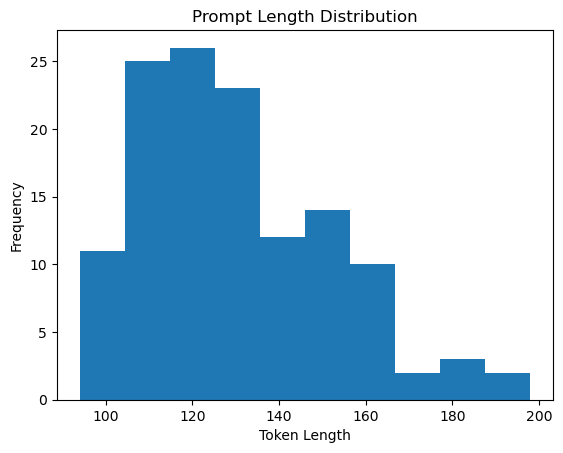

In [14]:
lengths = dataset["length"]

plt.hist(lengths)
plt.title("Prompt Length Distribution")
plt.xlabel("Token Length")
plt.ylabel("Frequency")
plt.show()

We select the first BATCH_SIZE samples without sorting.

In [15]:
subset = dataset.select(range(min(BATCH_SIZE, len(dataset))))

batch_inputs = {
    "input_ids": subset["input_ids"],
    "attention_mask": subset["attention_mask"],
}

batch_lengths = subset["length"]

print("Batch lengths:", batch_lengths)

Batch lengths: Column([135, 96, 127, 105, 181, ...])


In [16]:
padded_batch = tokenizer.pad(
    batch_inputs,
    return_tensors="pt"
)

print("Padded shape:", padded_batch["input_ids"].shape)

Padded shape: torch.Size([32, 181])


In [17]:
def move_to_device(batch: dict) -> dict:
    return {k: v.to(device) for k, v in batch.items()}


@torch.no_grad()
def generate_batch(
    model, batch, max_new_tokens:int, do_sample=False, **generation_kwds
):
    model.eval()
    batch = move_to_device(batch)
    outputs = model.generate(
        input_ids=batch["input_ids"],
        attention_mask=batch.get("attention_mask"),
        max_new_tokens=max_new_tokens,
        do_sample=do_sample,
        use_cache=True,
        **generation_kwds
    )

    # Extract the completions
    outputs = outputs[:, batch["input_ids"].size(1) :]

    return outputs.cpu()

In [ ]:
start = time.perf_counter()
completions = generate_batch(model, padded_batch,max_new_tokens=MAX_NEW_TOKENS)
end = time.perf_counter()

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
/nfs/home/seymol/conda_envs/v3.13/lib/python3.13/site-packages/torch/backends/cuda/__init__.py:131: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:80.)
  return torch._C._get_cublas_allow_tf32()
/nfs/home/seymol/conda_envs/v3.13/lib/python3.13/site-packages/torch/_inductor/compile_fx.py:312: UserWarning: TensorFloat32 tensor cores for float32 matrix multiplicati

In [19]:
elapsed = end - start
print(f"Elapsed time: {elapsed:.4f} seconds\n")

print("Sample completion:\n")

Elapsed time: 30.3409 seconds

Sample completion:



## Clean Decoding: Remove Prompt and Special Tokens

`model.generate()` returns:

[prompt tokens | generated tokens]

We must:
1. Remove the original prompt length.
2. Decode only newly generated tokens.
3. Strip special tokens cleanly.

In [20]:
def decode_responses(
    tokenizer, generated_ids: torch.Tensor
) -> list[str]:
    """
    Extract only newly generated tokens (excluding prompt)
    and decode cleanly.
    """
    
    # Decode cleanly
    responses = tokenizer.batch_decode(
        generated_ids,
        skip_special_tokens=True,  # removes tokens like <eos>, <pad>, etc.
        # Post-processing step that fixes spacing artifacts such as:
        # "Hello , world !"  ->  "Hello, world!"
        # "do n ' t"         ->  "don't"
        # Useful for human-readable demos.
        # Should be avoided only when exact string fidelity is required.
        clean_up_tokenization_spaces=True,
    )

    return responses

In [21]:
responses = decode_responses(
    tokenizer=tokenizer, generated_ids=completions
)

In [22]:
Markdown(responses[0])

To determine how much Janet makes at the farmers' market each day, we need to follow these steps:

1. **Calculate the total number of eggs laid by the ducks:**
   - Janet's ducks lay 16 eggs per day.

2. **Determine the number of eggs eaten in a day:**
   - Janet eats 3 eggs for breakfast.
   - She also bakes muffins for her friends, which adds another 4 eggs.
   - Therefore, the total number of eggs eaten in a day is \(3 + 4 = 7\) eggs.

3. **Subtract the number of eggs eaten from the total number of eggs laid:**
   - Total eggs laid: 16
   - Eggs eaten: 7
   - Remaining eggs: \(16 - 7 = 9\) eggs

4. **Calculate the revenue from selling the remaining eggs:**
   - The price per fresh egg is $2.
   - Number of remaining eggs: 9
   - Revenue from selling the eggs: \(9 \times 2 = 18\) dollars

5. **Output the final amount:**
   \(\boxed{18}\)

## Compute the accuracy of the model

In [ ]:
# Simple prediction loop using generate_batch
all_responses = []

for i in tqdm(range(0, len(dataset), BATCH_SIZE)):
    batch = dataset[i : i + BATCH_SIZE]
    batch_inputs = {
        "input_ids": batch["input_ids"],
        "attention_mask": batch["attention_mask"],
    }
    padded_batch = tokenizer.pad(batch_inputs, return_tensors="pt")

    completions = generate_batch(
        model,
        padded_batch,
        max_new_tokens=MAX_NEW_TOKENS,
    )
    all_responses.extend(decode_responses(tokenizer, completions))

results = compute_accuracy(
    responses=all_responses,
    dataset=dataset,
)

print(f"Accuracy: {results['accuracy']:.4f}")
print(f"Correct: {results['correct']} / {results['total']}")


  0%|          | 0/4 [00:00<?, ?it/s]

Accuracy: 0.3438
Correct: 44 / 128
